<a href="https://colab.research.google.com/github/a-03-k/Titanic_survival/blob/main/VIT_Capstone_ph1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Anjani K

#Artificial Intelligence and Machine Learning: Phase 1
#Basic Data Insights
#Dataset-Specific Analysis
#Correlation Analysis

In [2]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Basic Data Insights:
#Load and explore the structure of each dataset.
#Analyze missing values in the datasets.
df1_chefmozaccepts = pd.read_csv('/content/chefmozaccepts.csv')
df2_chefmozcuisine = pd.read_csv('/content/chefmozcuisine.csv')
df3_chefmozhours4 = pd.read_csv('/content/chefmozhours4.csv')
df4_chefmozparking = pd.read_csv('/content/chefmozparking.csv')
df5_geoplaces2 = pd.read_csv('/content/geoplaces2.csv')
df6_rating_final = pd.read_csv('/content/rating_final.csv')
df7_usercuisine = pd.read_csv('/content/usercuisine.csv')
df8_userpayment = pd.read_csv('/content/userpayment.csv')
df9_userprofile = pd.read_csv('/content/userprofile.csv')

In [4]:
df1_chefmozaccepts.head()#accepts

,placeID,Rpayment
0,135110,cash
1,135110,VISA
2,135110,MasterCard-Eurocard
3,135110,American_Express
4,135110,bank_debit_cards


In [5]:
df1_chefmozaccepts.shape

(1314, 2)

In [6]:
df1_chefmozaccepts.isnull().sum()

,0
placeID,0
Rpayment,0


In [7]:
#df1.unique()
df1_chefmozaccepts.nunique()

,0
placeID,615
Rpayment,12


In [8]:
df1_chefmozaccepts['Rpayment'].value_counts()

,count
Rpayment,
cash,500
MasterCard-Eurocard,194
VISA,172
American_Express,153
bank_debit_cards,130
Visa,83
Diners_Club,42
Discover,11
checks,10


# The Rpayment shows the various modes of payments by the customers as cash, MasterCard-Eurocard, visa, American_Express etc.

In [9]:
df2_chefmozcuisine.head()# cuisine

,placeID,Rcuisine
0,135110,Spanish
1,135109,Italian
2,135107,Latin_American
3,135106,Mexican
4,135105,Fast_Food


In [10]:
df2_chefmozcuisine.shape

(916, 2)

In [11]:
df2_chefmozcuisine.isnull().sum()

,0
placeID,0
Rcuisine,0


In [64]:
df2_chefmozcuisine['Rcuisine'].value_counts().nlargest(20).index

Index(['Mexican', 'International', 'American', 'Dutch-Belgian', 'Italian',
       'Greek', 'Bar', 'French', 'Cafe-Coffee_Shop', 'Pizzeria',
       'Bar_Pub_Brewery', 'Cafeteria', 'Chinese', 'Fast_Food', 'Seafood',
       'Japanese', 'Family', 'German', 'Mediterranean', 'Burgers'],
      dtype='object', name='Rcuisine')

# sorting the most popular cuisines

In [13]:
# 1. Count how many restaurants serve each cuisine
cuisine_counts = df2_chefmozcuisine['Rcuisine'].value_counts()

# 2. Getting the name and count of the least popular ones
most_popular_name = cuisine_counts.idxmax()
most_popular_count = cuisine_counts.max()

print(f"The most popular cuisine is: {most_popular_name} (found in {most_popular_count} restaurant)")

The most popular cuisine is: Mexican (found in 239 restaurant)


# visualizations for the popular cuisines using a count plot to find all values.

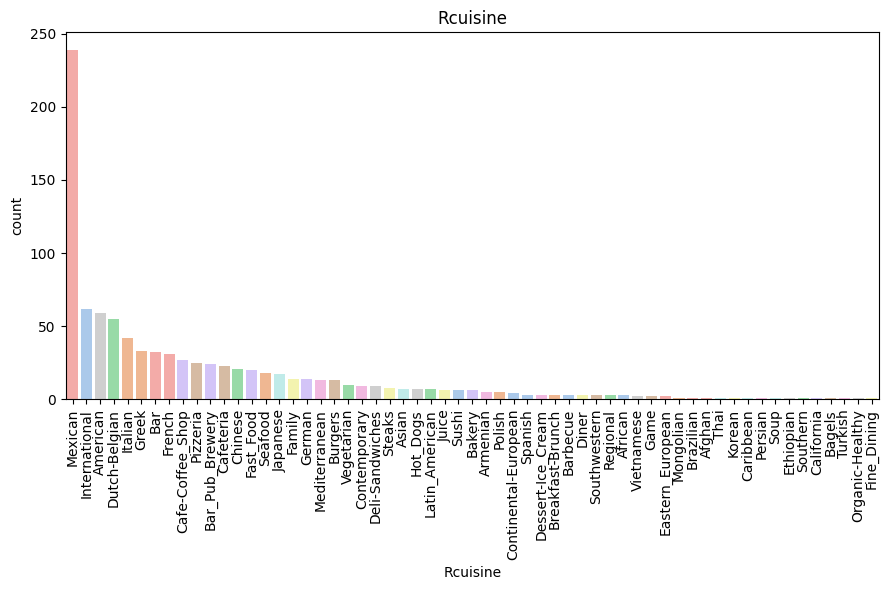

In [14]:
plt.figure(figsize=(9,6))
sns.countplot(data= df2_chefmozcuisine, x= 'Rcuisine', hue='Rcuisine', palette = 'pastel', order=df2_chefmozcuisine['Rcuisine'].value_counts().index, legend= False)
plt.title('Rcuisine')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('variety_of_cuisines.png')
plt.show()

In [15]:
df3_chefmozhours4.head()

,placeID,hours,days
0,135111,00:00-23:30;,Mon;Tue;Wed;Thu;Fri;
1,135111,00:00-23:30;,Sat;
2,135111,00:00-23:30;,Sun;
3,135110,08:00-19:00;,Mon;Tue;Wed;Thu;Fri;
4,135110,00:00-00:00;,Sat;


In [16]:
df3_chefmozhours4.shape#chefmozhours

(2339, 3)

In [17]:
df3_chefmozhours4.isnull().sum()

,0
placeID,0
hours,0
days,0


In [18]:
df3_chefmozhours4[['hours','days']].value_counts()

hours         days                
00:00-23:30;  Sun;                    243
              Sat;                    225
              Mon;Tue;Wed;Thu;Fri;    213
00:00-00:00;  Sun;                     49
              Sat;                     27
                                     ... 
06:00-23:30;  Sat;                      1
06:30-15:00;  Mon;Tue;Wed;Thu;Fri;      1
06:30-17:00;  Mon;Tue;Wed;Thu;Fri;      1
01:00-20:30;  Mon;Tue;Wed;Thu;Fri;      1
01:00-01:00;  Sat;                      1
Name: count, Length: 613, dtype: int64

# visualize the operating hours and days to find out most popular days.

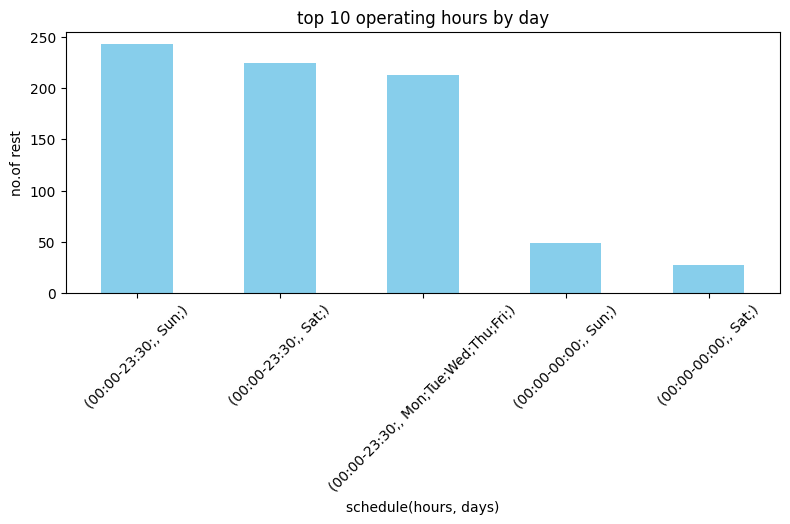

In [19]:
# visualizations
import matplotlib.pyplot as plt
hour_counts = df3_chefmozhours4[['hours', 'days']].value_counts().head()
plt.figure(figsize = (8,6))
hour_counts.plot(kind ='bar', color ='skyblue')
plt.title('top 10 operating hours by day')
plt.xlabel('schedule(hours, days)')
plt.ylabel("no.of rest")
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('operating_hours.png')
plt.show()

#This graph shows that Sunday and saturday are the most busy days operating hours by day'

In [20]:
df4_chefmozparking.head()

,placeID,parking_lot
0,135111,public
1,135110,none
2,135109,none
3,135108,none
4,135107,none


In [21]:
df4_chefmozparking.shape

(702, 2)

In [22]:
df4_chefmozparking['parking_lot'].unique()

array(['public', 'none', 'yes', 'valet parking', 'fee', 'street',
       'validated parking'], dtype=object)

In [23]:
df4_chefmozparking.isnull().sum()

,0
placeID,0
parking_lot,0


# visualize the vehicle parking availability

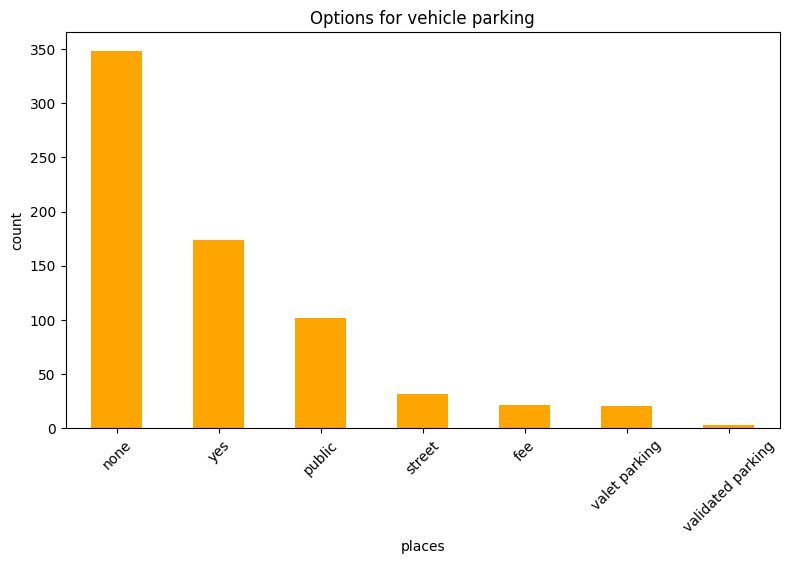

In [24]:
# visualize the parking availability
parking_places_available = df4_chefmozparking['parking_lot'].value_counts()

plt.figure(figsize = (8,6))
parking_places_available.plot(kind ='bar', color ='orange')
plt.title('Options for vehicle parking')
plt.xlabel('places')
plt.ylabel("count")
plt.tight_layout()
plt.xticks(rotation=45)
plt.savefig('parking_places_available.png')
plt.show()

#This graph for parking availabilty shows that most restaurants have no parking lots available, some provide parking at their restaurants, while others have some paid parkings along with options like public parking, street, and valet options.

In [25]:
df5_geoplaces2.head(2)

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,parking area,other_services
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none


In [26]:
df5_geoplaces2.columns

Index(['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'address',
       'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area',
       'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise',
       'parking area', 'other_services'],
      dtype='object')

In [27]:
df5_geoplaces2.shape

(130, 21)

In [28]:
df5_geoplaces2.isnull().sum()

,0
placeID,0
latitude,0
longitude,0
the_geom_meter,0
name,0
address,0
city,0
state,0
country,0
fax,0


In [29]:
df6_rating_final.head()

,userID,rating,food_rating,service_rating
0,U1077,2,2,2
1,U1077,2,2,1
2,U1077,2,2,2
3,U1077,1,2,2
4,U1068,1,1,2


In [30]:
df6_rating_final.shape

(1161, 4)

In [31]:
df6_rating_final.isnull().sum()

,0
userID,0
rating,0
food_rating,0
service_rating,0


In [32]:
df7_usercuisine.head()

,userID,Rcuisine
0,U1001,American
1,U1002,Mexican
2,U1003,Mexican
3,U1004,Bakery
4,U1004,Breakfast-Brunch


In [33]:
df7_usercuisine.isnull().sum()

,0
userID,0
Rcuisine,0


In [34]:
df8_userpayment.head()

,userID,Upayment
0,U1001,cash
1,U1002,cash
2,U1003,cash
3,U1004,cash
4,U1004,bank_debit_cards


In [35]:
df8_userpayment.shape

(177, 2)

In [36]:
df8_userpayment.isnull().sum()

,0
userID,0
Upayment,0


In [38]:
df9_userprofile.head(3)# userprofile

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69


In [39]:
df9_userprofile.columns.nunique()

19

In [40]:
df9_userprofile.columns

Index(['userID', 'latitude', 'longitude', 'smoker', 'drink_level',
       'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos',
       'birth_year', 'interest', 'personality', 'religion', 'activity',
       'color', 'weight', 'budget', 'height'],
      dtype='object')

In [41]:
df9_userprofile.shape

(138, 19)

In [42]:
df9_userprofile.isnull().sum()

,0
userID,0
latitude,0
longitude,0
smoker,0
drink_level,0
dress_preference,0
ambience,0
transport,0
marital_status,0
hijos,0


# visualize the payments methods by customers by creating a pieplot

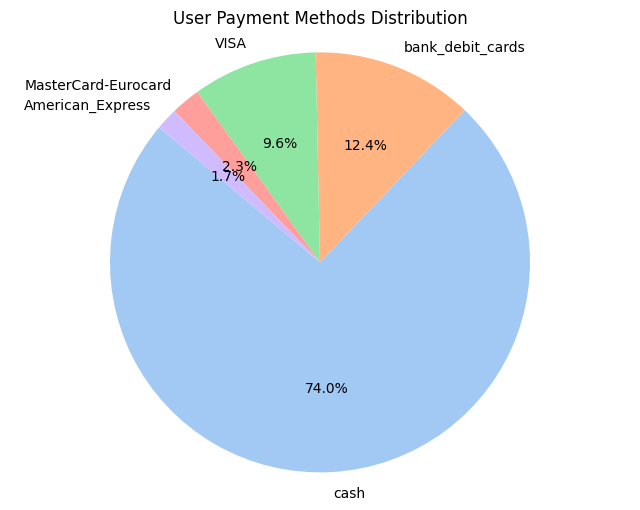

In [43]:
# distribution of payment methods
payment_counts = df8_userpayment['Upayment'].value_counts()
sizes = payment_counts.values
labels = payment_counts.index
colors = sns.color_palette('pastel')[0:len(labels)]


plt.figure(figsize = (8,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)

plt.axis('equal')
plt.title('User Payment Methods Distribution')
plt.savefig('userpayment.png')
plt.show()

#The piechart shows that the users prefer to pay most commonly by cash and then comes other modes as bank debit cards, visa, Mastercard-Eurocard and American Express

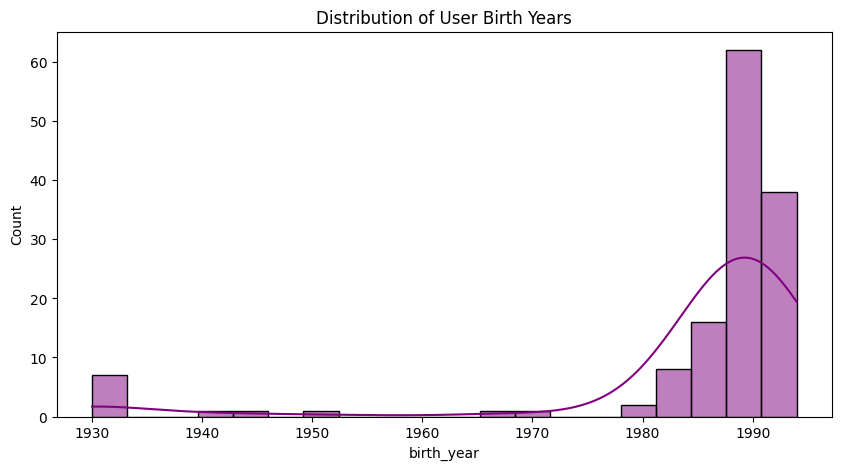

In [44]:
##Birth year and religious preferences.
# Distribution of Birth Years
plt.figure(figsize=(10, 5))
sns.histplot(df9_userprofile['birth_year'], bins=20, kde=True, color='purple')
plt.title('Distribution of User Birth Years')
plt.show()

# The graph shows that most customers are from the years between 1980 to 1990. It is also visible that the graph is right skewed.

In [46]:
#Analyze user demographics: smoker, drink level, transport, marital status, budget, personality, and interests.
demo_cols = ['smoker','drink_level', 'transport','marital_status', 'budget', 'personality','interest']

for col in demo_cols:
    print(f' distribution of {col}')
    print(df9_userprofile[col].value_counts())
    print('\n')


 distribution of smoker
smoker
false    109
true      26
?          3
Name: count, dtype: int64


 distribution of drink_level
drink_level
abstemious        51
casual drinker    47
social drinker    40
Name: count, dtype: int64


 distribution of transport
transport
public       82
car owner    35
on foot      14
?             7
Name: count, dtype: int64


 distribution of marital_status
marital_status
single     122
married     10
?            4
widow        2
Name: count, dtype: int64


 distribution of budget
budget
medium    91
low       35
?          7
high       5
Name: count, dtype: int64


 distribution of personality
personality
hard-worker            61
thrifty-protector      58
hunter-ostentatious    12
conformist              7
Name: count, dtype: int64


 distribution of interest
interest
variety         50
technology      36
none            30
eco-friendly    16
retro            6
Name: count, dtype: int64




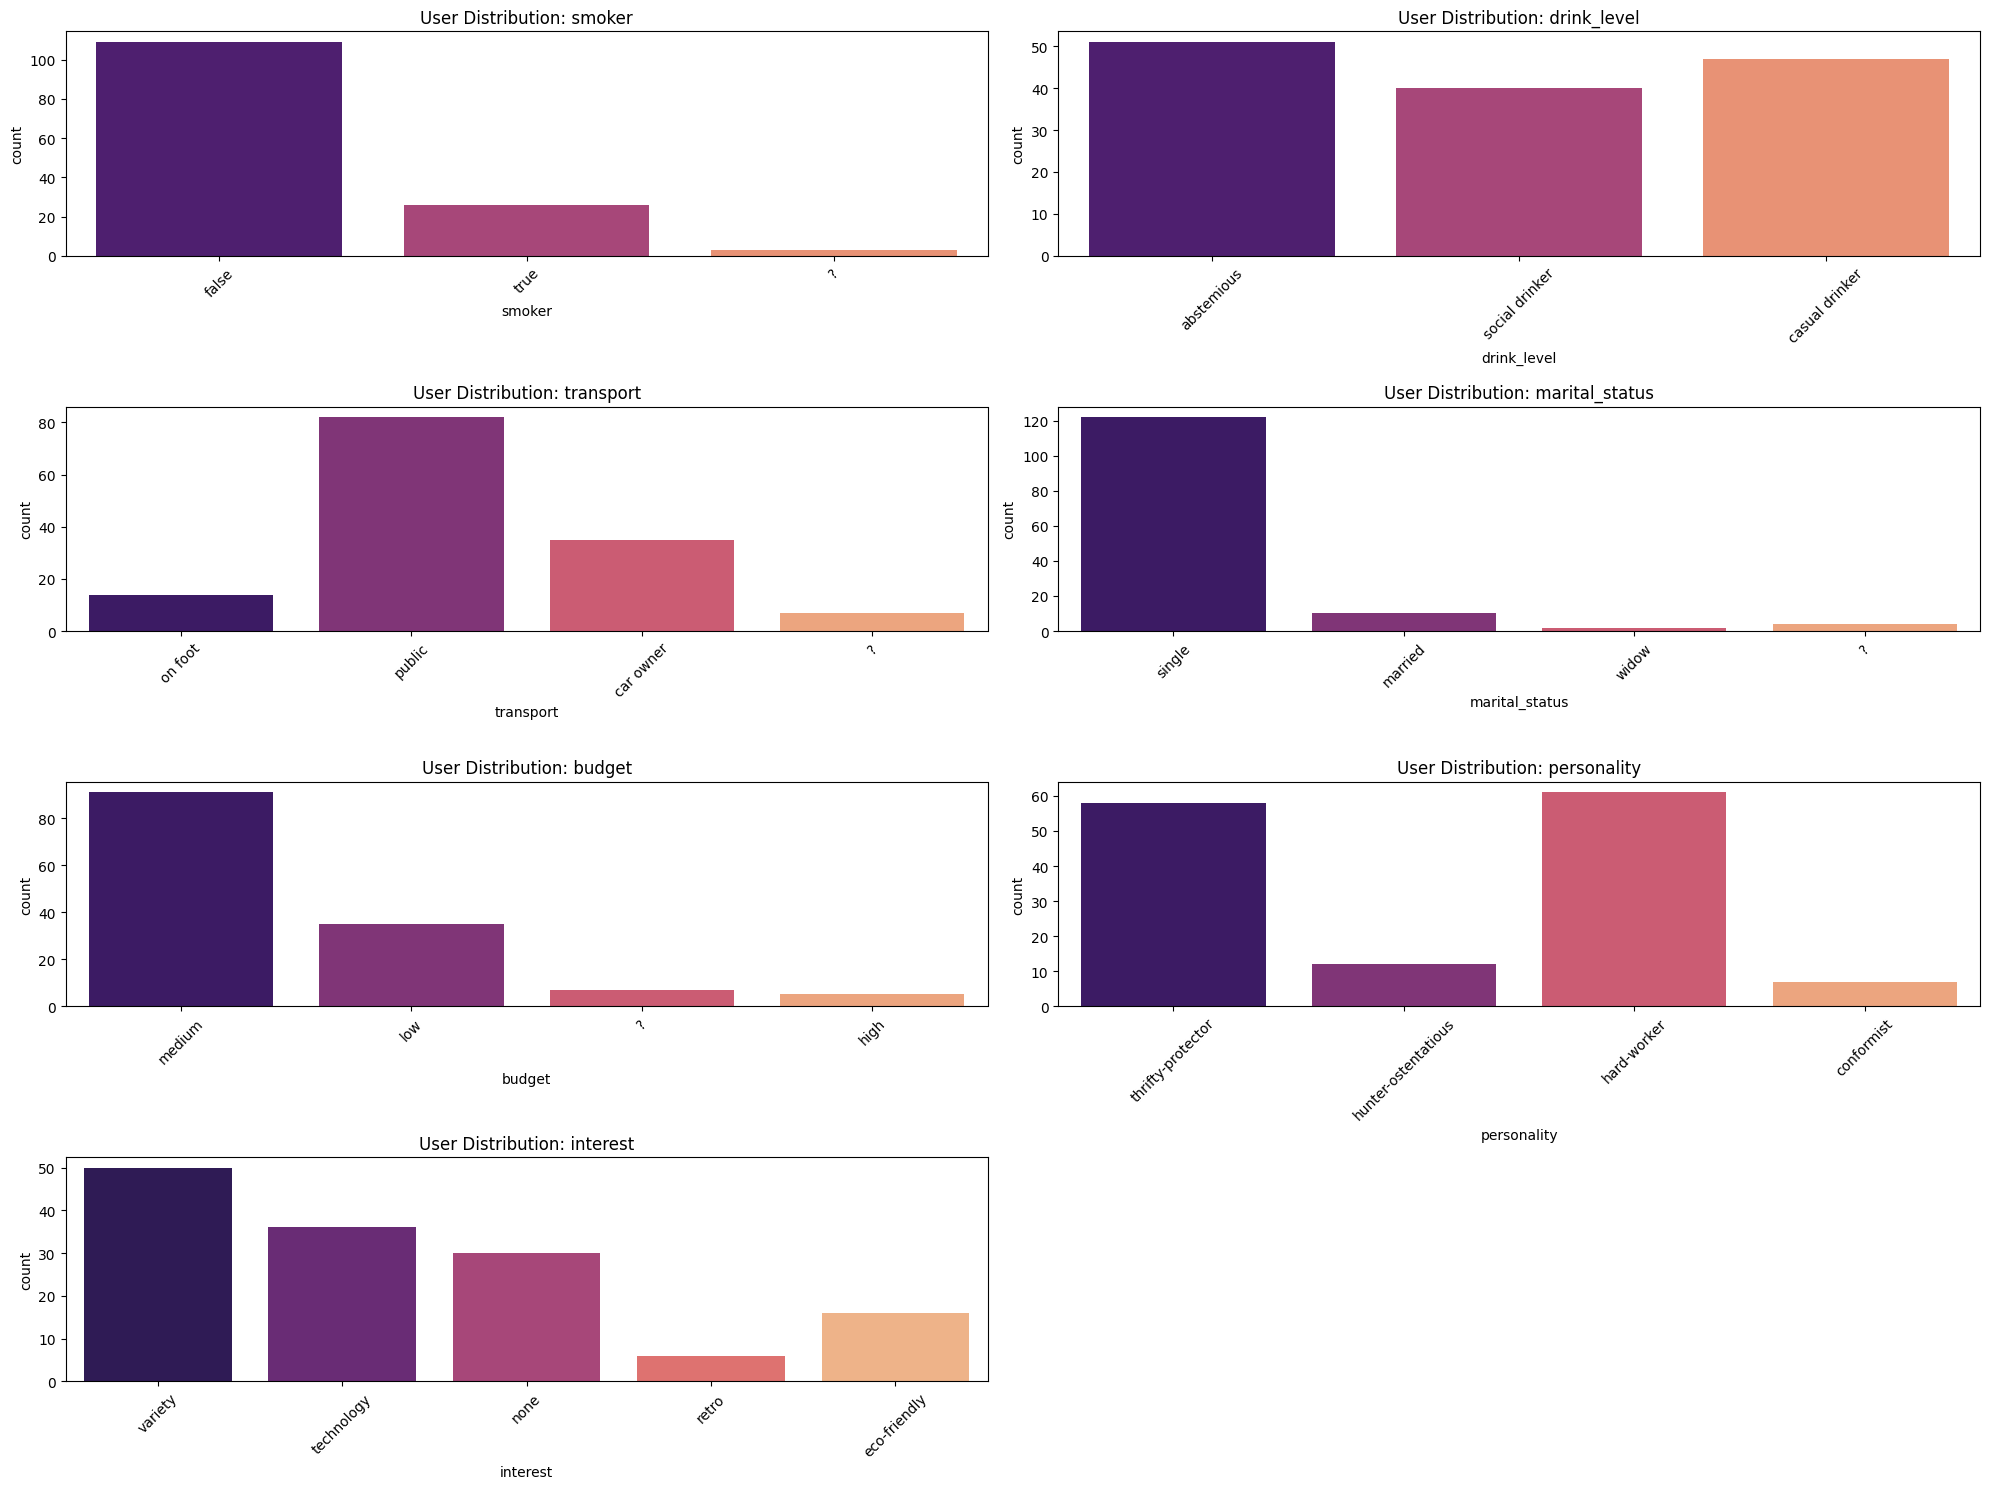

In [47]:
plt.figure(figsize=(20,15))


for i, col in enumerate(demo_cols):

    plt.subplot(4, 2, i + 1)

    sns.countplot(data = df9_userprofile, hue = col, x=col, palette = 'magma', legend = False)
    plt.title(f'User Distribution: {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# The charts show that majority of users rely on public transport and second choice being cars.
#The demographics shows that most people are single.
#Most users fall into medium budget category.
# maximum number of people are non smokers.
# more number of people are abstemious drinker followed by casual and social drinkers.
# The personality distribution shows maximum number of people are hard workers followed by thrifty protectors and hunters.


In [47]:
#Correlation Analysis:
#Explore correlations between restaurant features (price, latitude, longitude).


In [49]:
# encoding the price column using ordinal encoding
price_mapping = {'low':1, 'medium':2,'high':3,'free':4}
df5_geoplaces2['price'] = df5_geoplaces2['price'].map(price_mapping)

In [81]:
# selecting features for correlation
features =['price','latitude','longitude']
corr_matrix = df5_geoplaces2[features].corr()
print(corr_matrix)


              price  latitude  longitude
price      1.000000 -0.153301  -0.278968
latitude  -0.153301  1.000000  -0.243800
longitude -0.278968 -0.243800   1.000000


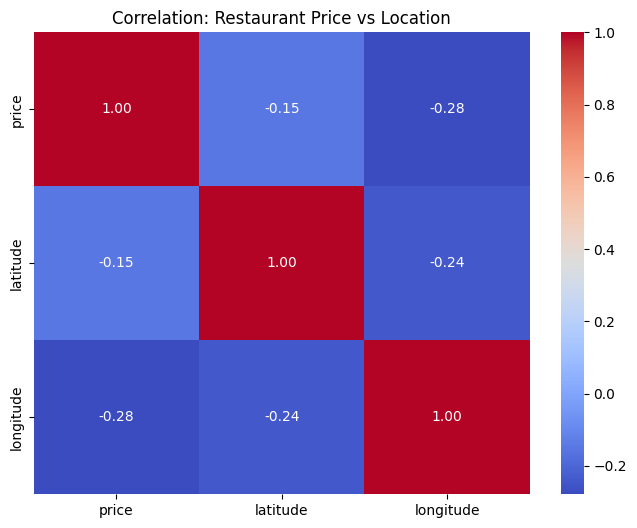

In [82]:
# 3. Visualize with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Restaurant Price vs Location')
plt.savefig('user_physical_features.png', bbox_inches='tight', dpi=300)
plt.savefig('heatmap.pdf')
plt.show()

The heatmap shows that price is highly correlated with the location of the restaurants. This means that the restaurants are clustered in some places with these specific latitude and longitudes

In [87]:
# @title
#Explore correlations between user features (latitude, longitude, weight, height)
df9_userprofile.head(2)

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87


In [83]:
features =['latitude','longitude','weight','height']
corr_matrix = df9_userprofile[features].corr()
print(corr_matrix)

           latitude  longitude   weight    height
latitude   1.000000  -0.275157  0.12263  0.065063
longitude -0.275157   1.000000  0.14113  0.000956
weight     0.122630   0.141130  1.00000  0.535570
height     0.065063   0.000956  0.53557  1.000000


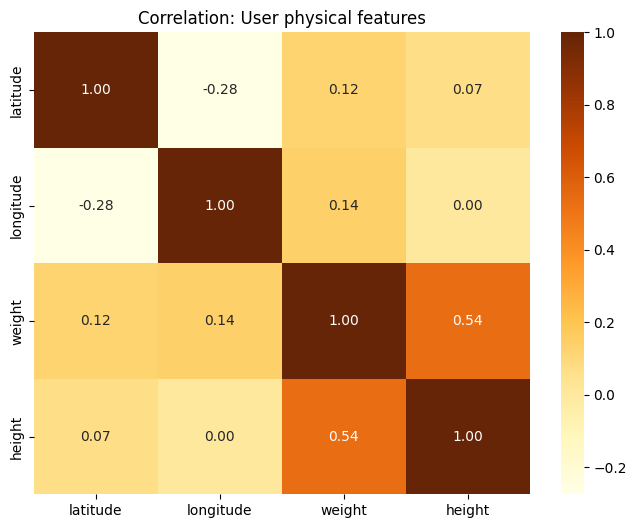

In [84]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrBr', fmt='.2f')
plt.title('Correlation: User physical features')

plt.savefig('heatmap.pdf')
plt.show()

This heatmap shows that there is a strong correlation between height and weight of the people (0.54) which is understood, while the geographic location does not correlate with the physical features anywhere(-0.28) means negatively correlated.